In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [10]:
# lets load up data
df = pd.read_csv("student-scores.csv")
df.head(10)
# df.describe()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76
5,6,Kelly,Wade,kelly.wade.6@gslingacademy.com,female,False,2,False,26,Unknown,93,100,67,78,72,80,84
6,7,Anthony,Smith,anthony.smith.7@gslingacademy.com,male,False,3,True,23,Software Engineer,99,96,97,73,88,76,64
7,8,George,Short,george.short.8@gslingacademy.com,male,True,2,True,34,Software Engineer,95,95,82,63,84,70,85
8,9,Stanley,Gutierrez,stanley.gutierrez.9@gslingacademy.com,male,False,6,False,25,Unknown,94,68,94,85,81,74,72
9,10,Audrey,Simpson,audrey.simpson.10@gslingacademy.com,female,False,3,True,18,Teacher,98,69,88,71,67,71,73


In [8]:
# df['career_aspiration'].value_counts()

# List of subject columns
subject_columns = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']

# Calculate the average score for each subject
average_scores = df[subject_columns].mean()

# Print the average scores
print(average_scores)


print("Report: There is a high success pass in all subjects with math math as the highest and biology as the least")

math_score         83.4520
history_score      80.3320
physics_score      81.3365
chemistry_score    79.9950
biology_score      79.5815
english_score      81.2775
geography_score    80.8880
dtype: float64
Highest Performing Subject: math_score with an average score of 83.45
Lowest Performing Subject: biology_score with an average score of 79.58
Report: There is a high success pass in all subjects with math math as the highest and biology as the least


Correlation between Weekly Self-Study Hours and Average Score: 0.502


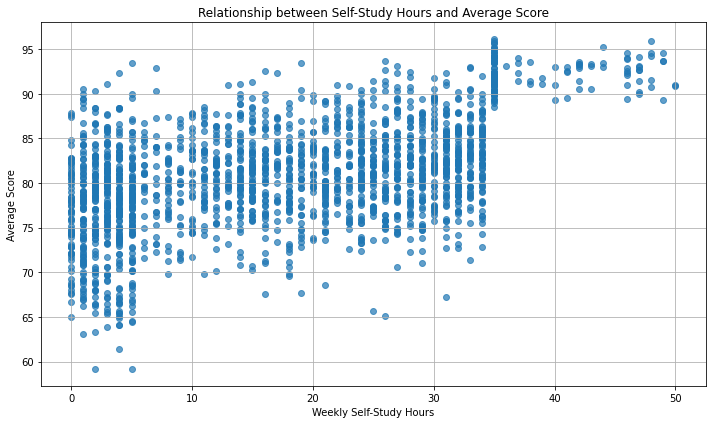

In [22]:
# Correlation between student study hours and their average score

# List of subject columns
subject_columns = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']
df['average_score'] = df[subject_columns].mean(axis = 1)

# student_score_correlation = df[['id'] + df['Average score']].corr()

study_hour_correlation = df[['weekly_self_study_hours', 'average_score']].corr()['weekly_self_study_hours']['average_score']
print(f"Correlation between Weekly Self-Study Hours and Average Score: {study_hour_correlation:.3f}")
print("Report: The correlation between student study hours and their average score is approximately 0.5 thats half")

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.scatter(df['weekly_self_study_hours'], df['average_score'], alpha=0.7)  # alpha for better visibility
plt.xlabel("Weekly Self-Study Hours")
plt.ylabel("Average Score")
plt.title("Relationship between Self-Study Hours and Average Score")
plt.grid(True)  # Add gridlines for better readability
plt.tight_layout()
plt.show()



In [23]:
# correlation of students study hours to each of their subject scores
# Calculate the correlation between weekly_self_study_hours and each subject score
correlation_matrix = df[
    ["weekly_self_study_hours"] + subject_columns
].corr()

# Extract the correlations with weekly_self_study_hours
study_hours_correlation = correlation_matrix[
    "weekly_self_study_hours"
].drop("weekly_self_study_hours")

# Print the correlations
print("Correlation between Weekly Self-Study Hours and Subject Scores:")
print(study_hours_correlation)



Correlation between Weekly Self-Study Hours and Subject Scores:
math_score         0.393569
history_score      0.276231
physics_score      0.202120
chemistry_score    0.201340
biology_score      0.190481
english_score      0.247796
geography_score    0.153622
Name: weekly_self_study_hours, dtype: float64


Correlation between Weekly Self-Study Hours and Subject Scores:
math_score         0.393569
history_score      0.276231
physics_score      0.202120
chemistry_score    0.201340
biology_score      0.190481
english_score      0.247796
geography_score    0.153622
Name: weekly_self_study_hours, dtype: float64


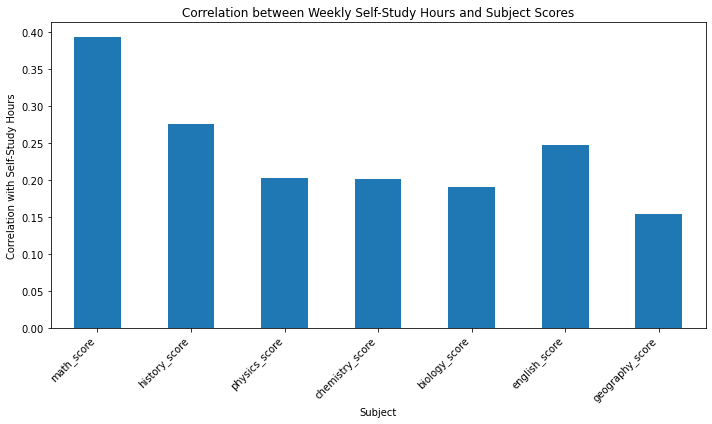

In [63]:
# How do weekly self-study hours impact students’ scores across different subjects?

# Calculate the correlation between weekly_self_study_hours and each subject score
correlation_matrix = df[['weekly_self_study_hours'] + subject_columns].corr()

# Extract the correlations with weekly_self_study_hours
study_hours_correlation = correlation_matrix['weekly_self_study_hours'].drop(
    'weekly_self_study_hours'
)

# Print the correlations
print("Correlation between Weekly Self-Study Hours and Subject Scores:")
print(study_hours_correlation)


study_hours_correlation.plot(kind='bar', figsize=(10, 6))
plt.xlabel("Subject")
plt.ylabel("Correlation with Self-Study Hours")
plt.title("Correlation between Weekly Self-Study Hours and Subject Scores")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Unique values in 'part_time_job' column:
[False  True]


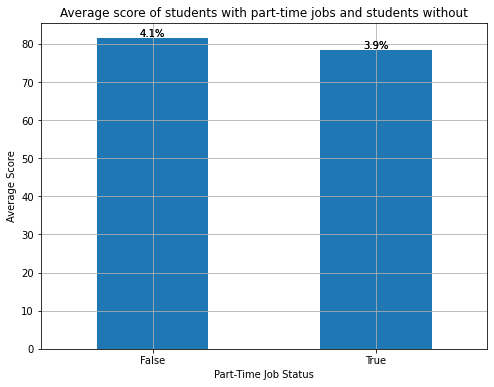

Report: 2% of People without part time jobs have a higher average score 


In [51]:
# Do students with part-time jobs perform differently compared to those without jobs?

# Load the dataset
df = pd.read_csv("student-scores.csv")

# List of subject columns
subject_columns = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']
df['average_score'] = df[subject_columns].mean(axis = 1)


# Print unique values in 'part_time_job' column
print("Unique values in 'part_time_job' column:")
print(df['part_time_job'].unique())


# Group by part-time job status and calculate the mean of 'average_score'
average_scores_by_job = df.groupby('part_time_job')['average_score'].mean()


# Create the bar chart
average_scores_by_job.plot(kind='bar', figsize=(8, 6))
ax = average_scores_by_job.plot(kind='bar', figsize=(8, 6))
plt.xlabel("Part-Time Job Status")
plt.ylabel("Average Score")
plt.title("Average score of students with part-time jobs and students without")
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.grid(True)
# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total) # Changed to use p.get_height()
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.text(x, y, percentage, ha='center', va='bottom')

plt.show()


print("Report: 2% of students without part time jobs have a higher average score ")



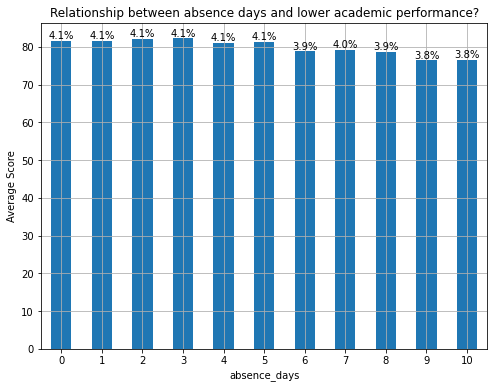

In [54]:
# Is there a relationship between absence days and lower academic performance?


# Load the dataset
df = pd.read_csv("student-scores.csv")

# List of subject columns
subject_columns = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']
df['average_score'] = df[subject_columns].mean(axis = 1)


#Group performance by absence days
absence_days_by_average_score = df.groupby('absence_days')['average_score'].mean()


# Create the bar chart
ap = absence_days_by_average_score.plot(kind='bar', figsize=(8, 6))
plt.xlabel("absence_days")
plt.ylabel("Average Score")
plt.title("Relationship between absence days and lower academic performance?")
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.grid(True)
# Add percentage labels
total = len(df)
for p in ap.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total) # Changed to use p.get_height()
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ap.text(x, y, percentage, ha='center', va='bottom')

plt.show()

print("Report: Increase in number of Absence days affects average score of students")

Unique values in 'extracurricular_activities' column:
[False  True]


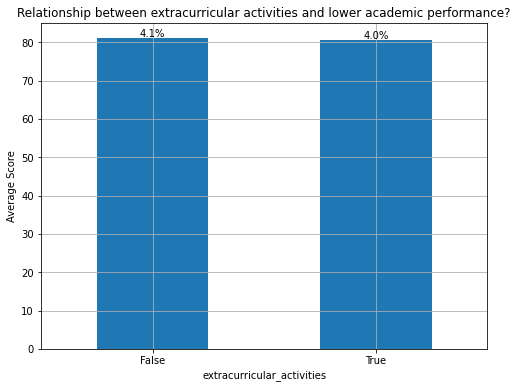

Report: Increase in number of Absence days affects average score


In [55]:
# Do extracurricular activities help or hurt student performance?

# Load the dataset
df = pd.read_csv("student-scores.csv")



# List of subject columns
subject_columns = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']
df['average_score'] = df[subject_columns].mean(axis = 1)


#Group performance by absence days
extracurricular_activities_by_average_score = df.groupby('extracurricular_activities')['average_score'].mean()


# Create the bar chart
ap = extracurricular_activities_by_average_score.plot(kind='bar', figsize=(8, 6))
plt.xlabel("extracurricular_activities")
plt.ylabel("Average Score")
plt.title("Relationship between extracurricular activities and lower academic performance?")
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.grid(True)
# Add percentage labels
total = len(df)
for p in ap.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total) # Changed to use p.get_height()
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ap.text(x, y, percentage, ha='center', va='bottom')

plt.show()

print("Report: The impact of extracurricular activities on the average score affects only 1% of students")

The subject with the strongest correlation with overall academic success is math_score with a correlation coefficient of 0.51


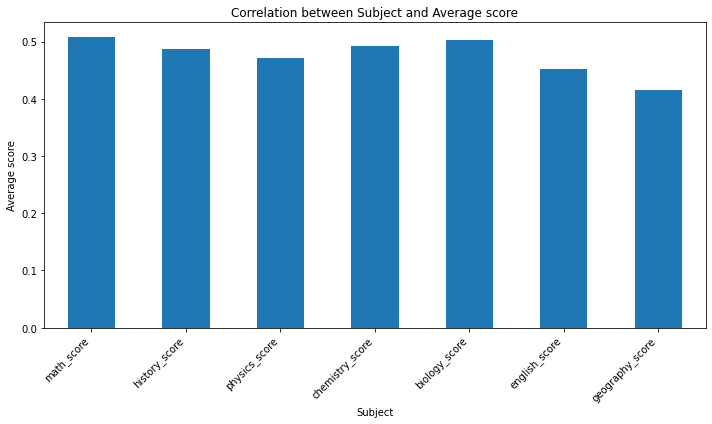

In [62]:
# Which subject has the strongest correlation with overall academic success?

# Load the dataset
df = pd.read_csv("student-scores.csv")

# List of subject columns
subject_columns = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']
df['average_score'] = df[subject_columns].mean(axis = 1)


# Calculate the correlation between each subject and the overall average score.
correlations = df[subject_columns].corrwith(df['average_score'])

# Find the subject with the strongest correlation.
strongest_correlation_subject = correlations.abs().idxmax()
strongest_correlation_value = correlations.abs().max()

print(f"The subject with the strongest correlation with overall academic success is {strongest_correlation_subject} with a correlation coefficient of {strongest_correlation_value:.2f}")




correlations.plot(kind='bar', figsize=(10, 6))
plt.xlabel("Subject")
plt.ylabel("Average score")
plt.title("Correlation between Subject and Average score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Correlation matrices for each career aspiration:
                                   math_score  history_score  physics_score  \
career_aspiration                                                             
Accountant        math_score         1.000000      -0.004831      -0.009228   
                  history_score     -0.004831       1.000000      -0.094053   
                  physics_score     -0.009228      -0.094053       1.000000   
                  chemistry_score    0.132506       0.214716      -0.103791   
                  biology_score     -0.058107       0.009220       0.140144   
...                                       ...            ...            ...   
Writer            physics_score      0.237334      -0.135825       1.000000   
                  chemistry_score    0.051586      -0.103907       0.346969   
                  biology_score      0.002811       0.175557      -0.101247   
                  english_score      0.035074      -0.210355       0.263153   
  

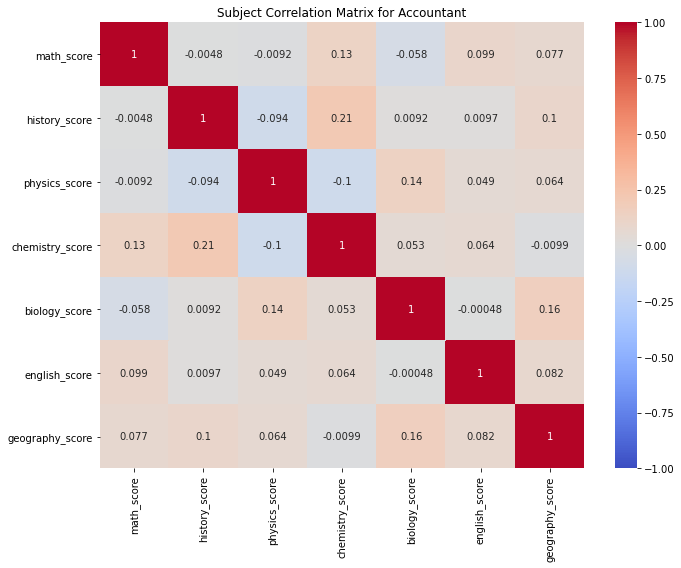

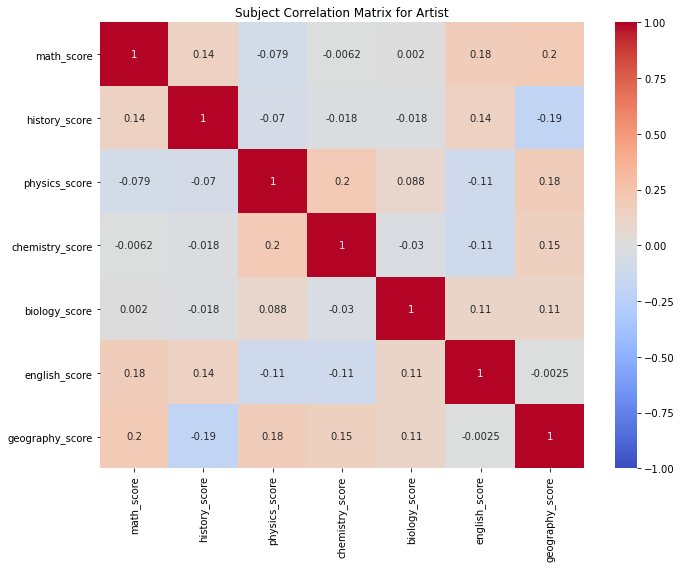

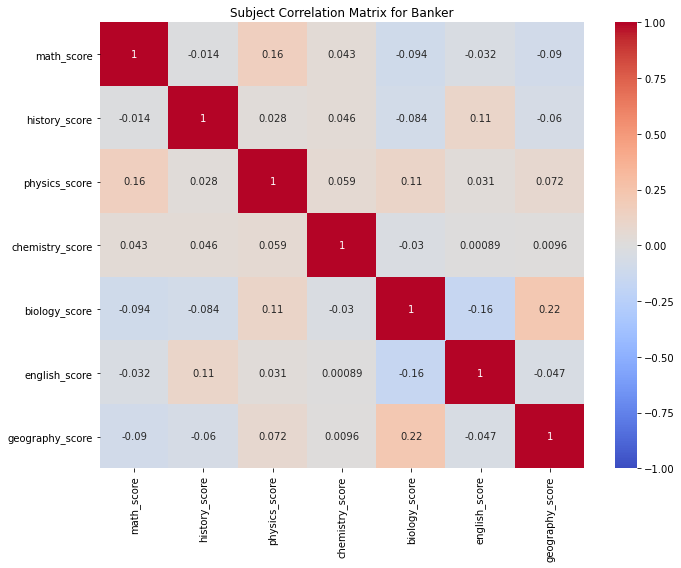

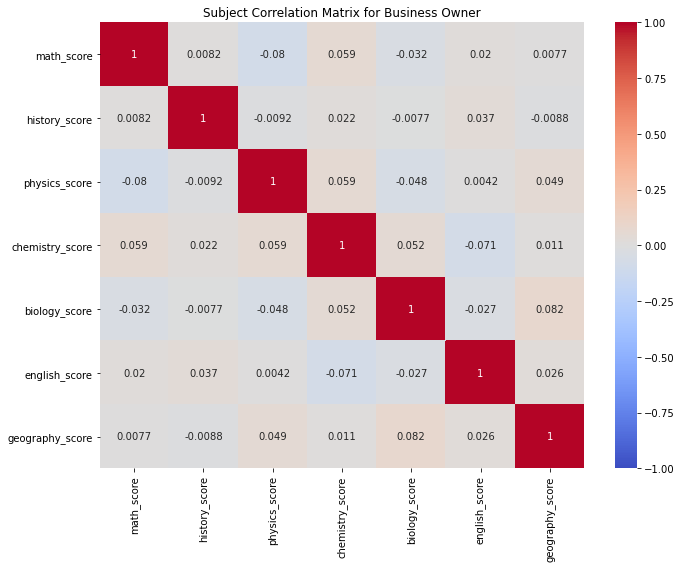

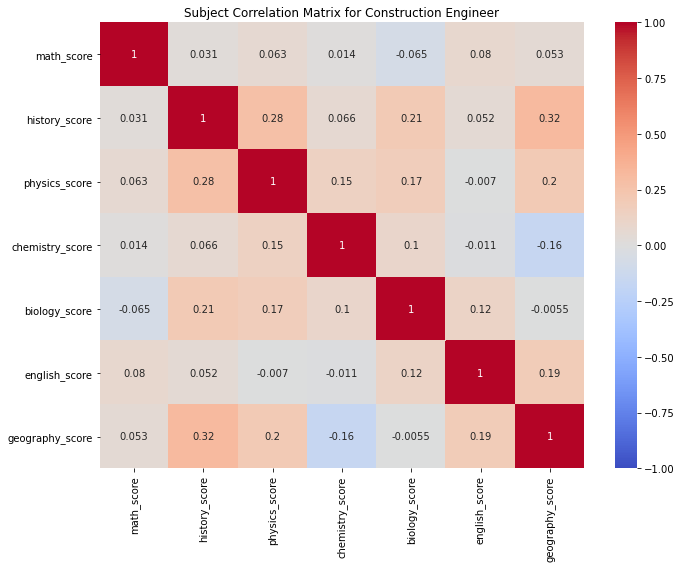

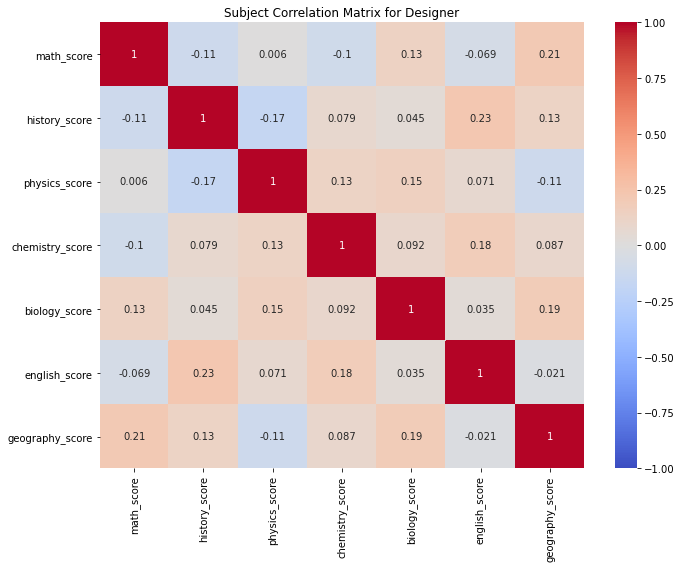

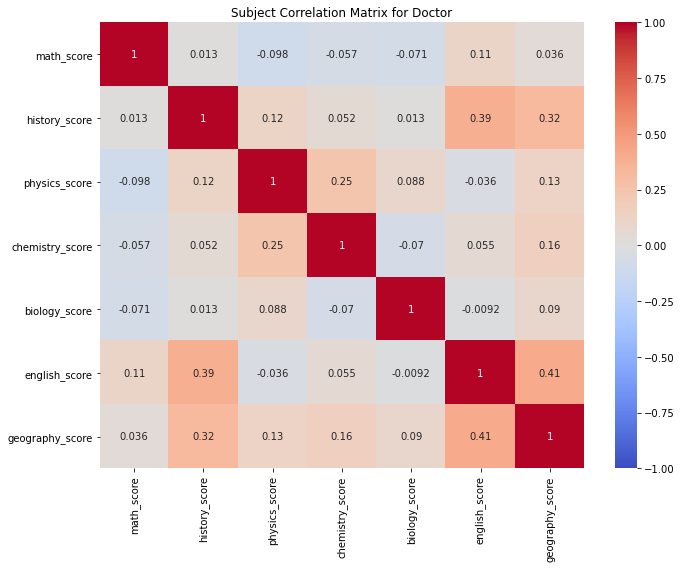

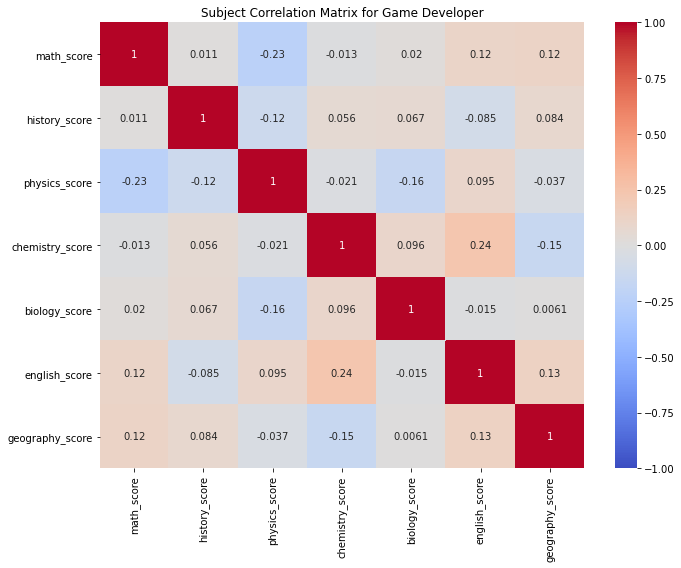

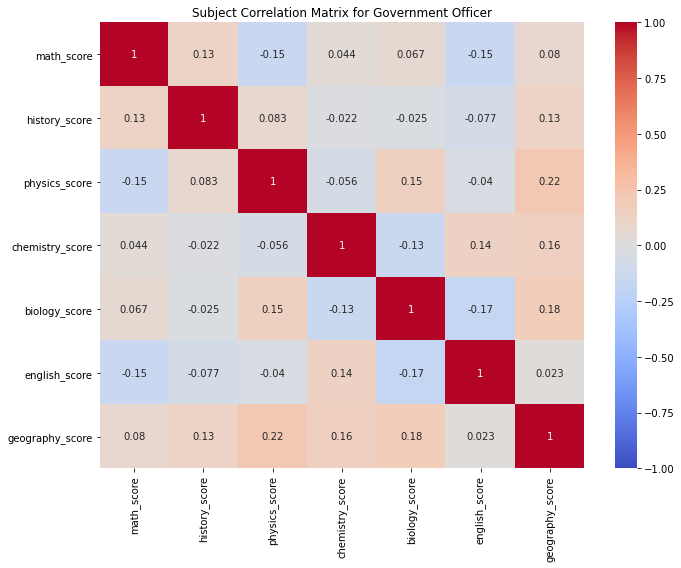

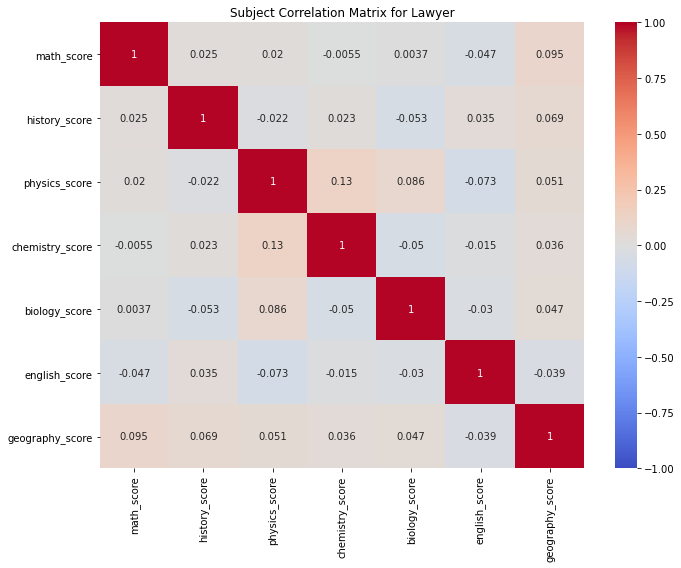

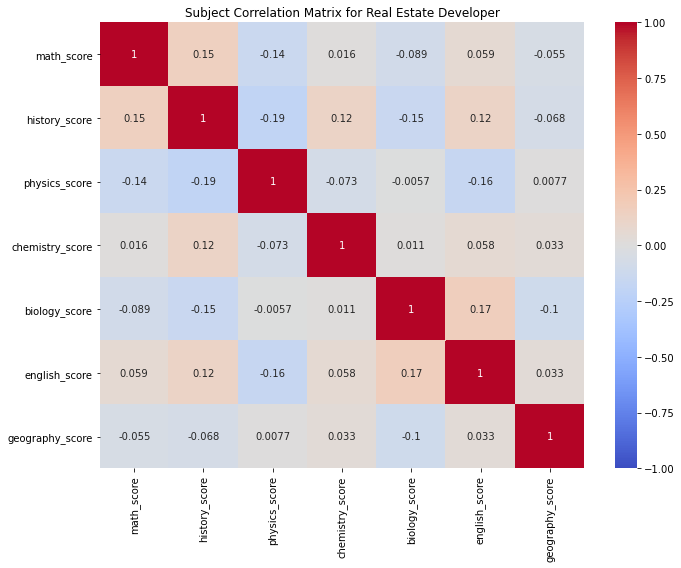

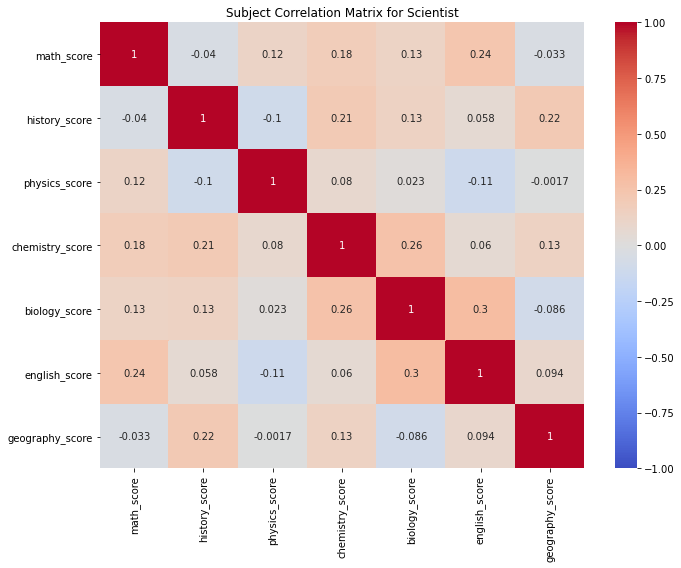

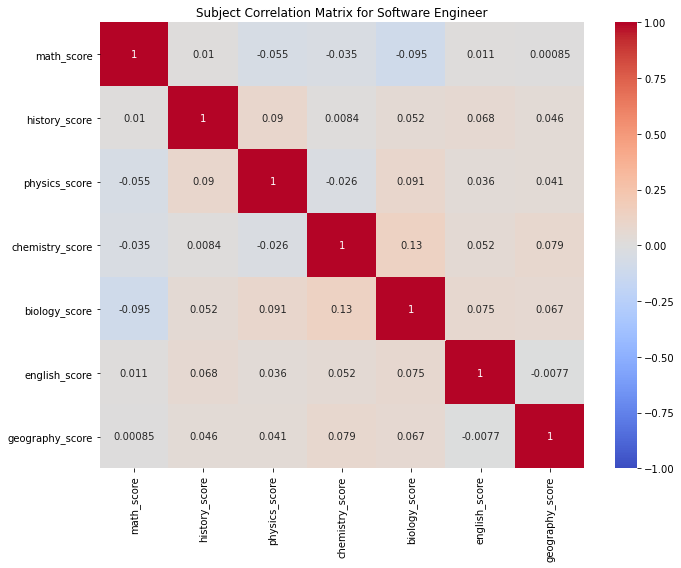

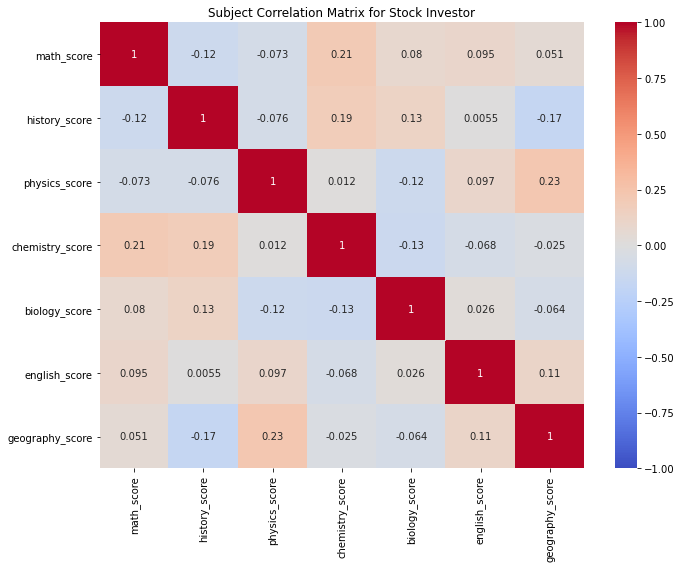

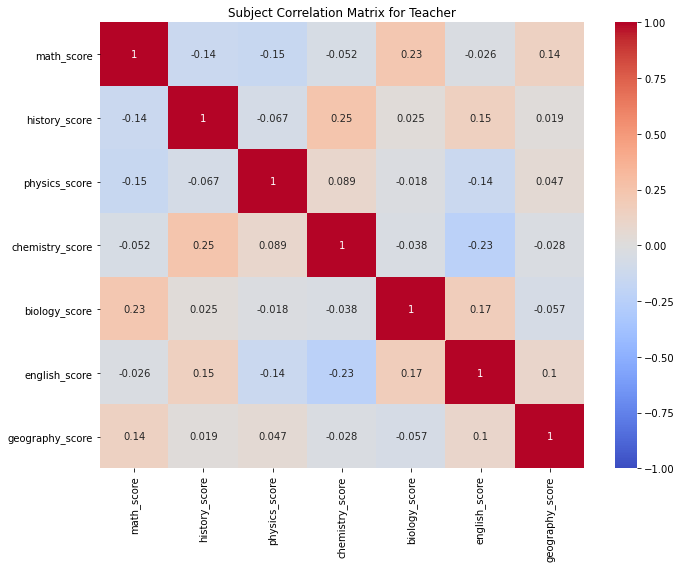

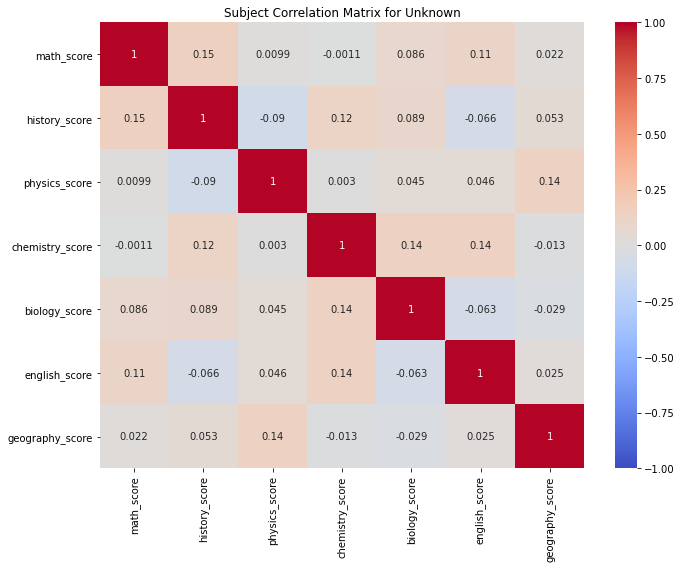

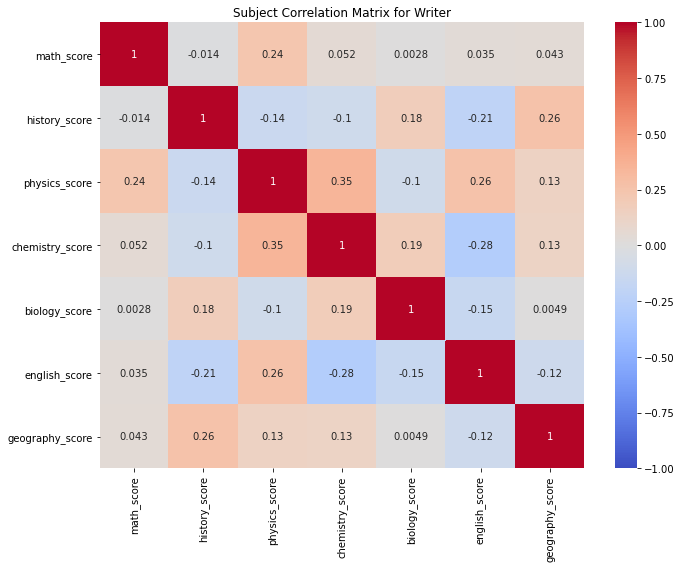

In [66]:
# Look for correlations between scores in different subjects based on career aspiration.
import seaborn as sns

# Load the dataset
df = pd.read_csv("student-scores.csv")

# List of subject columns
subject_columns = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']
df['average_score'] = df[subject_columns].mean(axis = 1)


# Group by career aspiration and calculate the correlation matrix for each group
grouped_correlations = df.groupby('career_aspiration')[subject_columns].corr()

# Print the correlation matrix for each career aspiration group
print("\nCorrelation matrices for each career aspiration:")
print(grouped_correlations)


for career, group_df in df.groupby('career_aspiration'):
    plt.figure(figsize=(10, 8))
    plt.title(f"Subject Correlation Matrix for {career}")
    sns.heatmap(group_df[subject_columns].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.tight_layout()
    plt.show()

math_score         83.4520
history_score      80.3320
physics_score      81.3365
chemistry_score    79.9950
biology_score      79.5815
english_score      81.2775
geography_score    80.8880
dtype: float64
Report: Math has the highest score in students accross all other subjects


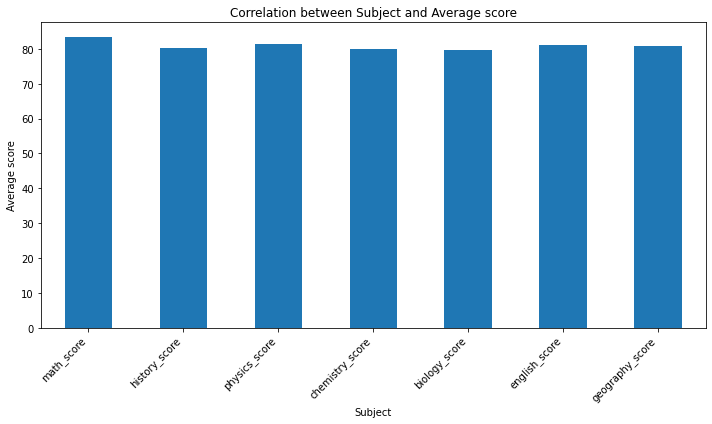

In [71]:
# Compare the distribution of scores for different subjects 

# Load your dataset
df = pd.read_csv("student-scores.csv")  # Replace with your actual file name

# List of subject columns
subject_columns = [
    "math_score",
    "history_score",
    "physics_score",
    "chemistry_score",
    "biology_score",
    "english_score",
    "geography_score",
]

# Calculate the average score for each subject
average_scores = df[subject_columns].mean()

# Print the average scores
print(average_scores)
print("Report: Math has the highest score in students accross all other subjects")

ab = average_scores.plot(kind='bar', figsize=(10, 6))
plt.xlabel("Subject")
plt.ylabel("Average score")
plt.title("Relationship between Subjects and Average score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
total = len(df)
plt.show()

Unique values in 'part_time_job' column:
[False  True]


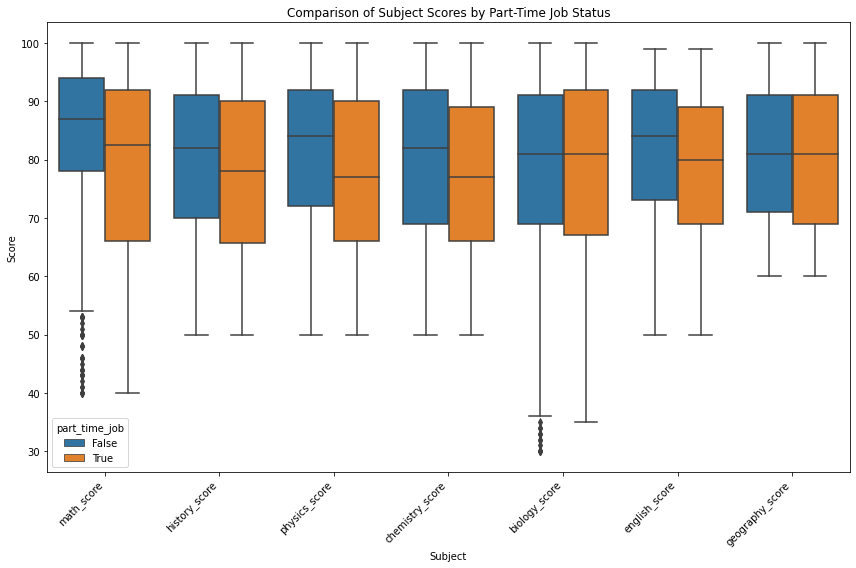

In [74]:
# subjects part time job students score higher in than students with no part time jobs

# Compare the distribution of scores for different subjects 

# Load your dataset
df = pd.read_csv("student-scores.csv")  # Replace with your actual file name

# List of subject columns
subject_columns = [
    "math_score",
    "history_score",
    "physics_score",
    "chemistry_score",
    "biology_score",
    "english_score",
    "geography_score",
]

# Print unique values in 'part_time_job' column
print("Unique values in 'part_time_job' column:")
print(df['part_time_job'].unique())

# Melt the dataframe to have a long format for easier plotting
melted_df = pd.melt(df, id_vars='part_time_job', value_vars=subject_columns, var_name='subject', value_name='score')

# Create a grouped boxplot to compare subject scores by part-time job status
plt.figure(figsize=(12, 8))
sns.boxplot(x='subject', y='score', hue='part_time_job', data=melted_df)
plt.xlabel("Subject")
plt.ylabel("Score")
plt.title("Comparison of Subject Scores by Part-Time Job Status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [77]:
#Student with the highest average score

# Load your dataset
df = pd.read_csv("student-scores.csv")  # Replace with your actual file name

# List of subject columns
subject_columns = [
    "math_score",
    "history_score",
    "physics_score",
    "chemistry_score",
    "biology_score",
    "english_score",
    "geography_score",
]

# Calculate the average score for each student across all subjects
df['average_score'] = df[subject_columns].mean(axis=1)

# Find the index of the student with the highest average score
highest_scorer_index = df['average_score'].idxmax()

# Get the row of the student with the highest average score
highest_scorer = df.loc[highest_scorer_index]

print("The student with the highest average score is:")
print(highest_scorer)

full_name = f"{highest_scorer['first_name']} {highest_scorer['last_name']}"
career = highest_scorer['career_aspiration']
print(f"\nTheir name is: {full_name}, and their career aspiration is {career}")


The student with the highest average score is:
id                                                            797
first_name                                                   Lisa
last_name                                                Mitchell
email                         lisa.mitchell.797@gslingacademy.com
gender                                                     female
part_time_job                                               False
absence_days                                                    3
extracurricular_activities                                   True
weekly_self_study_hours                                        35
career_aspiration                                          Banker
math_score                                                     87
history_score                                                  99
physics_score                                                  99
chemistry_score                                               100
biology_score                

# Overall Analysis Report
- There is a high success pass in all subjects with math math as the highest and biology as the least
- Students have a higher average score in math than in any other subjects
- The correlation between student study hours and their average score is approximately 0.5 that implies that the hours students put into study affects impacts their overall score performance
- The correlation between students scores in each subject and their self study hours is 
  - math: 0.39 (the highest),
  - history_score: 0.28, 
  - english_score:0.24, 
  - physics_score:0.2,
  - chemistry_score:  0.2, 
  - biology_score:0.19,
  - geography_score: 0.153622
- The correlation between career aspiration and subjects are:
  - Accountant: chemistry score and physcics score = 0.2
  - Writer: history score and Ggeography score = 0.26
  - Banker: biology score and geography score = 0.22
  - Construction Engineer: history score and geograpgy scores = 0.33
  - Designer: History score and English score = 0.23
  - Doctor: History score and English score = 0.39
  - Government Officer: Physics and geography score = 0.22
  - Scientist: math score and english score = 0.24
  - Unknown: history score and geography = 
  - Stock Inventor: physics score and geography score = 0.23
  - Teacher: biology score and math score = 0.23
  - 
  
 ## External factors
 
- The least average score of sudents with no part time job is higher than the least average score of students with part time job
- Students with part time job score higher in biology than students with no part time job.
- Students with high average absent days have a low average score
- Students with part time jobs have higher average of absence days leading to low average score
- Students with part time jobs have lesser weekly study hours
- Students that engage in extracurricular activities with no part time job have a higher average score than students that do not engage in extra curricular activities
